#### Columns

>* age
>* sex
>* chest pain type (4 values)
>* resting blood pressure
>* serum cholestoral in mg/dl
>* fasting blood sugar > 120 mg/dl
>* resting electrocardiographic results (values 0,1,2)
>* maximum heart rate achieved
>* exercise induced angina
>* oldpeak = ST depression induced by exercise relative to rest
>* the slope of the peak exercise ST segment
>* number of major vessels (0-3) colored by flourosopy
>* thal: 0 = normal; 1 = fixed defect; 2 = reversable defect

In [75]:
import pandas as pd

In [76]:
df = pd.read_csv("../data/raw/heart.csv")

In [77]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


> The goal is to predict wether the patient has a **heart disease** or not, based on the variables avaliable in this dataset.

### General analysis

In [78]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [79]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [80]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [81]:
df.loc[df["HeartDisease"] == 1]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
11,58,M,ATA,136,164,0,ST,99,Y,2.0,Flat,1
13,49,M,ASY,140,234,0,Normal,140,Y,1.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1


In [82]:
df.loc[df["HeartDisease"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
903,56,M,ATA,130,221,0,LVH,163,N,0.0,Up,0
904,56,M,ATA,120,240,0,Normal,169,N,0.0,Down,0
906,55,F,ATA,132,342,0,Normal,166,N,1.2,Up,0
910,41,M,ATA,120,157,0,Normal,182,N,0.0,Up,0


Out of a total of 918 patients, 410 do not have hart disease, while 508 do.

### Laboratorial variables

In [83]:
lab_columns = ["Cholesterol", "FastingBS"]

In [84]:
df[lab_columns].corr()

,Cholesterol,FastingBS
Cholesterol,1.000000,-0.260974
FastingBS,-0.260974,1.000000


There is a **negative** correlation between cholesterol and fasting blood sugar, suggesting an inverse relationship: when one variable rises, the other tends to fall.

Statistics for patients with high cholesterol and 

In [85]:
results = []
for col in lab_columns:

    group = df.groupby(col)["HeartDisease"]

    means = group.mean()
    medians = group.median()
    counting = group.count()

    mean_without = means.get(0)
    median_without = medians.get(0)
    count_without = counting.get(0)

    mean_with = means.get(1)
    median_with = medians.get(1)
    count_with = counting.get(1)

    results.append({
        "Condition": col,
        "Mean without heart disease": mean_without,
        "Median without heart disease": median_without,
        "Patients without heart disease": count_without,
        "Mean with heart disease": mean_with,
        "Median with heart disease": median_with,
        "Patients with heart disease": count_with

    }
    )

    conditions_table = pd.DataFrame(results)

conditions_table

,Condition,Mean without heart disease,Median without heart disease,Patients without heart disease,Mean with heart disease,Median with heart disease,Patients with heart disease
0,Cholesterol,0.883721,1.0,172,NaN,NaN,NaN
1,FastingBS,0.480114,0.0,704,0.794393,1.0,214.0


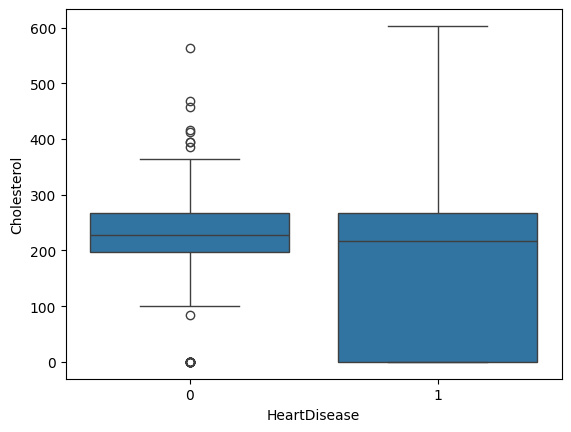

In [86]:
import seaborn as sns
sns.boxplot(x = "HeartDisease", y = "Cholesterol", data=df);

In [87]:
(df["Cholesterol"] == 0).sum()

np.int64(172)

There are many zero values for Cholesterol, which can indicate an error or missing data. So it's going to be replaced by "NaN".

#### Treating the 0 values in for Cholesterol

In [88]:
import numpy as np
df.loc[df["Cholesterol"] == 0, "Cholesterol"] = np.nan

##### Checking the boxplot again and analysing

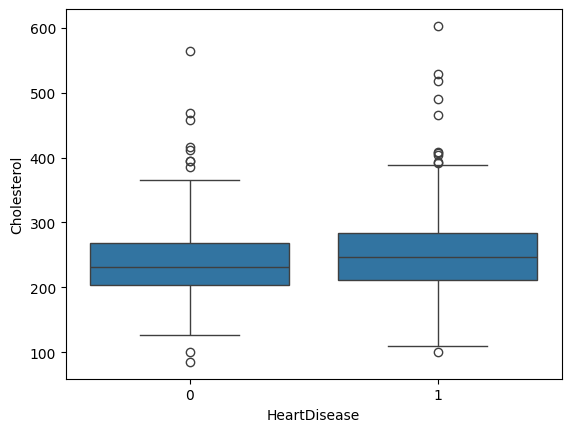

In [89]:
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df);

In [90]:
def calculate_outliers_by_group(df, column, target):
    grouped = df.groupby(target)[column]

    Q1 = grouped.quantile(.25)
    Q3 = grouped.quantile(.75)
    IQR = Q3 - Q1

    return pd.DataFrame({
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Limit": Q1 - 1.5 * IQR,
        "Upper Limit": Q3 + 1.5 * IQR
    })

In [91]:
calculate_outliers_by_group(df, "Cholesterol", "HeartDisease")

,Q1,Q3,IQR,Lower Limit,Upper Limit
HeartDisease,,,,,
0,203.0,269.00,66.00,104.000,368.000
1,212.0,283.25,71.25,105.125,390.125


##### Correlation between Cholesterol and HeartDisease

In [92]:
cholesterol_heart_corr = ["Cholesterol", "HeartDisease"]

df[cholesterol_heart_corr].corr()

,Cholesterol,HeartDisease
Cholesterol,1.000000,0.103866
HeartDisease,0.103866,1.000000


Altough there is a slight increase in choleterol levels among patients with heart disease, the distributions largely overlap. This suggeests that cholesterol alone may not be a strong discriminative feature for identifying heart disease in this dataset.

#### Analysing FastingBS

In [122]:
fastingbs_heart_corr = ["FastingBS", "HeartDisease"]
df[fastingbs_heart_corr].corr()

,FastingBS,HeartDisease
FastingBS,1.000000,0.267291
HeartDisease,0.267291,1.000000


In [123]:
df.loc[df["FastingBS"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
912,57,F,ASY,140,241.0,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264.0,0,Normal,132,N,1.2,Flat,1
915,57,M,ASY,130,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236.0,0,LVH,174,N,0.0,Flat,1


In [124]:
df.loc[df["FastingBS"] == 1]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
36,65,M,ASY,140,306.0,1,Normal,87,Y,1.5,Flat,1
38,48,F,ATA,120,177.0,1,ST,148,N,0.0,Up,0
52,45,M,ATA,140,224.0,1,Normal,122,N,0.0,Up,0
84,56,M,ASY,150,213.0,1,Normal,125,Y,1.0,Flat,1
86,65,M,ASY,170,263.0,1,Normal,112,Y,2.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
887,43,M,ASY,132,247.0,1,LVH,143,Y,0.1,Flat,1
888,52,M,ASY,128,204.0,1,Normal,156,Y,1.0,Flat,1
901,58,F,ASY,170,225.0,1,LVH,146,Y,2.8,Flat,1
911,59,M,ASY,164,176.0,1,LVH,90,N,1.0,Flat,1


Almost 77% of the patients have FastingBS greater than 120.

In [128]:
ct = pd.crosstab(df["FastingBS"], df["HeartDisease"], normalize="index")
ct

HeartDisease,0,1
FastingBS,,
0,0.519886,0.480114
1,0.205607,0.794393


In [129]:
odds_true = ct.loc[1, 1] / ct.loc[1, 0]
odds_false = ct.loc[0, 1] / ct.loc[0, 0]

odds_ratio = odds_true / odds_false

print(odds_ratio)

4.183700914470146


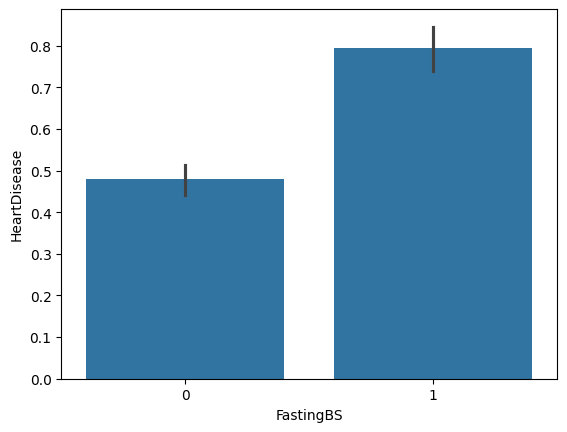

In [112]:
sns.barplot(x="FastingBS", y="HeartDisease", data=df);

79% of the patients with fasting blood sugar greater than 120 also have heart disease.

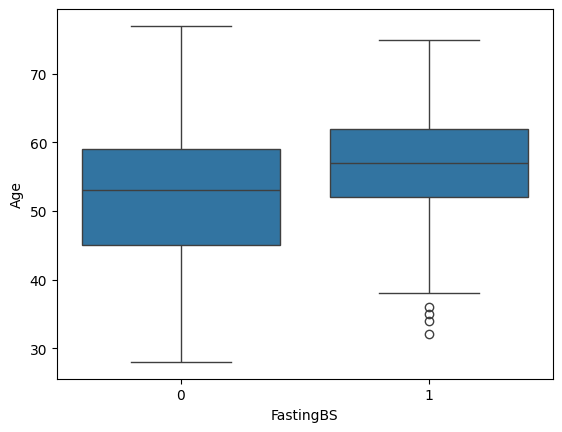

In [115]:
sns.boxplot(x="FastingBS", y="Age", data=df);

In [ ]:
fastinbs_age_corr = ["FastingBS", "HeartDisease"]
df[fastinbs_age_corr].corr()

,FastingBS,HeartDisease
FastingBS,1.000000,0.267291
HeartDisease,0.267291,1.000000


The proportion of heart disease is substantially higher among patients with elevated fasting blood sugar (~79%) compared to those withou (~48%). This results in a high odds ration (~4.18), indicating a strong association. However, this finding should be interpreted with caution due to the high prevalence of elevated fasting blood sugar in teh dataset, which may reflect a biased or high-risk population.

When comparing fasting blood sugar with patient age, the boxplot suggests that older patients tend to have higher fasting blood sugar levels. This observation is supported by a positive, although weak, correlation in the correlation matrix, indicating a slight association between age and fasting blood sugar.

### Demographic variables

In [ ]:
demographic = ["Age", "Sex"]

,Age,Sex
0,40,M
1,49,F
2,37,M
3,48,F
4,54,M
...,...,...
913,45,M
914,68,M
915,57,M
916,57,F


In [178]:
df["Elderly"] = df["Age"] >= 60
elderly_heart_disease = df.loc[(df["elderly"]) & (df["HeartDisease"])]

elderly_heart_disease

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,elderly,Elderly
18,60,M,ASY,100,248.0,0,Normal,125,N,1.0,Flat,1,True,True
36,65,M,ASY,140,306.0,1,Normal,87,Y,1.5,Flat,1,True,True
82,63,M,ASY,150,223.0,0,Normal,115,N,0.0,Flat,1,True,True
85,66,M,ASY,140,139.0,0,Normal,94,Y,1.0,Flat,1,True,True
86,65,M,ASY,170,263.0,1,Normal,112,Y,2.0,Flat,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,61,M,ASY,148,203.0,0,Normal,161,N,0.0,Up,1,True,True
905,67,M,NAP,152,212.0,0,LVH,150,N,0.8,Flat,1,True,True
908,63,M,ASY,140,187.0,0,LVH,144,Y,4.0,Up,1,True,True
909,63,F,ASY,124,197.0,0,Normal,136,Y,0.0,Flat,1,True,True


In [179]:
ct = pd.crosstab(df["Elderly"], df["HeartDisease"], normalize="index")
ct

HeartDisease,0,1
Elderly,,
False,0.514286,0.485714
True,0.268775,0.731225


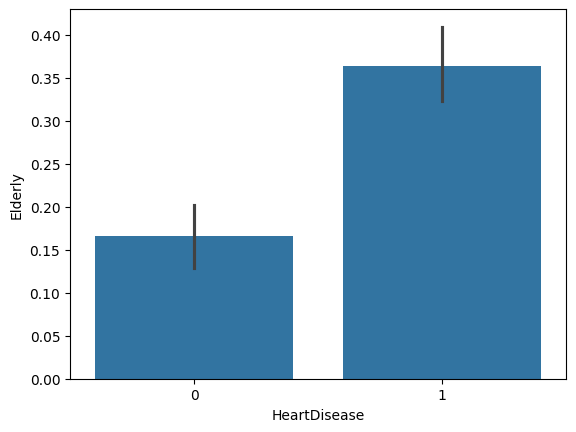

In [186]:
sns.barplot(x = "HeartDisease", y = "Elderly", data = df);

In [ ]:
The crosstab and barplot indicates that eldery (60 years old or more) patients have 

HeartDisease
1    1.0
Name: proportion, dtype: float64